# 01 — Signal trust: when is this EMG worth acting on?

> **Research question.** Can the input signal be trusted enough to enter a decision pipeline?

This is the first of three public notebooks (`01_signal_trust` → `02_confidence_under_shift` →
`03_when_not_to_help`). Together they are **offline, pilot-scale** evidence towards the Reborn
question — *how should an assistive robotic system decide when not to help?* — and nothing more:
they do not validate a device, a controller, a wearer-facing system, real-time operation, or a
safe assistance threshold.

This notebook covers **input trust**: two monitors that sit in front of any decision —

1. **Deterministic QC** (`reborn.sensing.emg_qc`): cheap, always-on, rule-based checks with named
   failure modes (dropout, saturation, clipping, amplitude range, baseline offset). The runtime
   safety path trusts these.
2. **Advisory anomaly detection** (`reborn.ml.anomaly`): a one-class detector that flags *"this
   does not look like the signal I was fit on"* without a per-mode rule. **Advisory only** — it is
   consumed through `reborn.decision.confidence_gate`, is never wired to actuators, and never
   overrides safety.

Both are evaluated against *injected* faults, and the notebook is careful to separate three
things that are easy to conflate: **signal failure**, **detector behaviour**, and the
**composition of the recording** the detector happens to be fit on.

## Scope box

| | |
|---|---|
| Dataset | Ninapro DB6 (public; downloaded locally, never committed — `data/README.md`) |
| Subjects | `s01` for the per-session QC audit and the fault/anomaly work; `s01`+`s02` in the cached window set the adaptive-threshold section reads |
| Sessions | 10 per subject (5 days × 2 sessions) |
| Montage | raw DB6 columns (0, 10), 2 channels |
| Preprocessing | `experiments/configs/ninapro_db6_qc.json`; config fingerprint printed below and stamped on every artifact |
| Window count | printed below (§1) and recorded in `nb01_run_<fingerprint>.json` |
| Mode | **OFFLINE** — recorded data replayed through the runtime's own QC and feature code |
| Scale | **PILOT** — one to two subjects; nothing here is a population estimate |

Everything the notebook measures is written to `experiments/results/nb01_*_<fingerprint>.csv`;
figures are rendered from those CSVs by `figures/render.py`, never from live kernel state.

## Setup

Run with the interpreter that has scipy and scikit-learn (`py -3.11` on the development machine;
`docs/research/phase-b-plan.md` §10). Thresholds are **not** the `emg_qc` defaults — those are
absolute values sized for signals of order 1, and DB6 samples are of order 1e-5 V. They come from
the committed config, derived from the data by `reborn.data.qc_calibration`, and §3 re-derives
them to show they are not stale.

One config detail that the prose must match: the committed pipeline runs with
`qc_powerline = False`. The mains-interference check exists in `emg_qc.check_powerline`, but it
costs a Welch PSD per window per channel and is switched off for full-dataset passes. **It plays
no part in any number below.**

In [1]:
import csv
import json
import sys
import time
from pathlib import Path

import numpy as np

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

from reborn.data.loaders import NinaproDB6Loader
from reborn.data.pipeline import (
    PreprocessConfig,
    build_window_set,
    load_window_set,
    preprocess,
    save_window_set,
    window_recording,
)
from reborn.data.qc_calibration import profile_amplitudes, suggest_corruption_kwargs, suggest_qc_thresholds
from reborn.ml.anomaly import AdaptiveThreshold, AnomalyDetector
from reborn.sensing import corruption
from reborn.sensing.emg_qc import assess_quality_report
from reborn.sensing.features import anomaly_features, extract_features

RESULTS = REPO / "experiments" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

CONFIG = json.loads((REPO / "experiments" / "configs" / "ninapro_db6_qc.json").read_text())
QC_KWARGS = CONFIG["qc_kwargs"]
MONTAGE = tuple(CONFIG["channels"]["montage"])
PRE = CONFIG["preprocess"]

print("montage (raw DB6 columns):", MONTAGE)
print("QC thresholds (committed config):")
for key, value in QC_KWARGS.items():
    print(f"  {key:<18}{value:.4g}   [{CONFIG['derivation'][key]}]")

montage (raw DB6 columns): (0, 10)
QC thresholds (committed config):
  min_rms           1.423e-07   [p0.1 of window RMS x 0.1]
  flatline_std      1.423e-07   [p0.1 of window RMS x 0.1]
  max_rms           0.0002952   [p99.9 of window RMS x 3.0]
  max_offset        5.735e-06   [p99.9 of |window mean| x 3.0]
  saturation_limit  0.001308   [p99.9 of window max|x| x 3.0]


In [2]:
config = PreprocessConfig(
    target_sample_rate=PRE["target_sample_rate_hz"],
    bandpass_hz=tuple(PRE["bandpass_hz"]),
    notch_hz=PRE["notch_hz"],
    window_ms=PRE["window_ms"],
    stride_ms=PRE["stride_ms"],
    pure_windows=PRE["pure_windows"],
    qc_kwargs=QC_KWARGS,
    # qc_channels stays None: the loader already narrowed the signal to MONTAGE, so by this
    # point channel 0 *is* raw column 0 and channel 1 *is* raw column 10.
    qc_channels=None,
)
STAMP = config.fingerprint()
print(f"window {config.window_samples} samples, stride {config.stride_samples}")
print(f"powerline check enabled: {config.qc_powerline}")
print("config fingerprint:", STAMP)

window 200 samples, stride 50
powerline check enabled: False
config fingerprint: fed1e81a523e5d6e


## 1. Dataset provenance

Recordings come from `reborn.data.loaders.NinaproDB6Loader`; loading, resampling, filtering,
windowing and the QC gate all go through `reborn.data`, which calls `reborn.sensing` — so what is
measured here is what the runtime code does, not a parallel implementation of it.

`SUBJECTS` and `SESSIONS` are the scope knobs. A full QC pass over one subject is ~136k windows
and takes a few minutes. Raising `stride_ms` would change the fingerprint, so results at different
strides must never be mixed into one table.

In [3]:
SUBJECTS = ["s01"]      # per-session QC audit and fault/anomaly work
SESSIONS = None         # None = every session

loader = NinaproDB6Loader(REPO / "data" / "ninapro_db6", channels=MONTAGE)
index = loader.index()
print(f"{len(index)} files on disk, subjects: {loader.subjects()}")
print("sessions per subject:", sorted({session for _, session, _ in index}))

sample_recording = next(loader.load(subjects=SUBJECTS[:1]))
prepared = preprocess(sample_recording, config)
print(f"\n{sample_recording.subject_id} / {sample_recording.session_id}")
print(f"  raw:      {sample_recording.n_samples} samples @ {sample_recording.sample_rate:.0f} Hz"
      f"  = {sample_recording.n_samples / sample_recording.sample_rate:.0f} s")
print(f"  prepared: {prepared.n_samples} samples @ {prepared.sample_rate:.0f} Hz, {prepared.n_channels} channels")
print(f"  classes:  {np.unique(prepared.labels)}   (0 = rest)")
print(f"  rest:     {float(np.mean(prepared.labels == 0)):.1%} of samples")

100 files on disk, subjects: ['s01', 's02', 's03', 's04', 's05', 's06', 's07', 's08', 's09', 's10']
sessions per subject: ['d01_t01', 'd01_t02', 'd02_t01', 'd02_t02', 'd03_t01', 'd03_t02', 'd04_t01', 'd04_t02', 'd05_t01', 'd05_t02']



s01 / d01_t01
  raw:      1428729 samples @ 2000 Hz  = 714 s
  prepared: 714365 samples @ 1000 Hz, 2 channels
  classes:  [ 0  1  3  4  6  9 10 11]   (0 = rest)
  rest:     25.4% of samples


## 2. QC rejection on real EMG, per session

The rejection rate is what the deterministic layer would have done at runtime: these are the
windows the system would refuse to act on. It is reported **per session** because the per-session
variation is the result — an average over sessions hides exactly the events that matter.

In [4]:
rejection_rows = []
started = time.time()
print(f"{'subject':<10}{'session':<12}{'windows':>10}{'rejected':>10}{'rate':>9}   reasons")
print("-" * 78)
for recording in loader.load(subjects=SUBJECTS, sessions=SESSIONS):
    _, _, qc = window_recording(preprocess(recording, config), config)
    rejection_rows.append(
        {
            "subject": recording.subject_id,
            "session": recording.session_id,
            "windows": qc.total,
            "rejected": qc.rejected,
            "rejection_rate": qc.rejection_rate,
            **{f"reason_{name}": n for name, n in qc.rejected_by_reason.items()},
        }
    )
    print(f"{recording.subject_id:<10}{recording.session_id:<12}{qc.total:>10}"
          f"{qc.rejected:>10}{qc.rejection_rate:>8.2%}   {qc.rejected_by_reason}")

total_windows = sum(row["windows"] for row in rejection_rows)
total_rejected = sum(row["rejected"] for row in rejection_rows)
print("-" * 78)
print(f"{'ALL':<22}{total_windows:>10}{total_rejected:>10}{total_rejected / total_windows:>8.2%}")
print(f"\n({time.time() - started:.0f} s)")

subject   session        windows  rejected     rate   reasons
------------------------------------------------------------------------------


s01       d01_t01          13616        36   0.26%   {'dropout': 36}


s01       d01_t02          13670         4   0.03%   {'dropout': 4}


s01       d02_t01          13622        11   0.08%   {'dropout': 11}


s01       d02_t02          13575        44   0.32%   {'dropout': 44}


...

s01       d03_t02          13657        67   0.49%   {'dropout': 67}


s01       d04_t01          13670       488   3.57%   {'dropout': 488}


s01       d04_t02          13569       192   1.41%   {'dropout': 192}


s01       d05_t01          13595        12   0.09%   {'dropout': 12}


s01       d05_t02          13653        25   0.18%   {'dropout': 25}
------------------------------------------------------------------------------
ALL                       136234       915   0.67%

(142 s)


In [5]:
rates = np.array([row["rejection_rate"] for row in rejection_rows])
median_rate = float(np.median(rates))
print(f"median {median_rate:.2%}   min {rates.min():.2%}   max {rates.max():.2%}")
print(f"max/median: {rates.max() / median_rate:.1f}x" if median_rate else "median is zero")
print("\nhighest-rejection sessions:")
for row in sorted(rejection_rows, key=lambda r: -r["rejection_rate"])[:4]:
    print(f"  {row['subject']}/{row['session']}  {row['rejection_rate']:.2%}")

median 0.26%   min 0.03%   max 3.57%
max/median: 13.5x

highest-rejection sessions:
  s01/d04_t01  3.57%
  s01/d04_t02  1.41%
  s01/d03_t02  0.49%
  s01/d02_t02  0.32%


## 3. What the thresholds are made of — staleness check

Re-derives the amplitude profile the committed thresholds came from. If these percentiles sat far
from the ones the config was built on, the config would be stale and the rejection rates above
would be measured against the wrong scale. The check is persisted (`nb01_threshold_staleness`),
not just printed.

In [6]:
profile = profile_amplitudes(loader.load(subjects=SUBJECTS[:1], sessions=SESSIONS))
summary = profile.summary()
print(f"{profile.n_windows} windows x {profile.n_channels} channels\n")
for stat in ("rms", "abs_mean", "abs_max"):
    print(f"{stat:<10}" + "  ".join(f"{k}={v:.3g}" for k, v in summary[stat].items()))

staleness_rows = []
print("\nthresholds these imply, vs. the committed config:")
for key, value in suggest_qc_thresholds(profile).items():
    ratio = value / QC_KWARGS[key] if QC_KWARGS.get(key) else float("nan")
    staleness_rows.append({"threshold": key, "rederived": value, "committed": QC_KWARGS[key], "ratio": ratio})
    print(f"  {key:<18}{value:.4g}   committed {QC_KWARGS[key]:.4g}   ratio {ratio:.2f}x")

20000 windows x 2 channels

rms       p0.1=1.42e-06  p1=1.79e-06  p50=1.62e-05  p99=7.39e-05  p99.9=9.84e-05
abs_mean  p0.1=2.01e-10  p1=1.64e-09  p50=1.21e-07  p99=1.17e-06  p99.9=1.91e-06
abs_max   p0.1=4.01e-06  p1=5.35e-06  p50=6.31e-05  p99=0.000308  p99.9=0.000436

thresholds these imply, vs. the committed config:
  min_rms           1.423e-07   committed 1.423e-07   ratio 1.00x
  flatline_std      1.423e-07   committed 1.423e-07   ratio 1.00x
  max_rms           0.0002952   committed 0.0002952   ratio 1.00x
  max_offset        5.735e-06   committed 5.735e-06   ratio 1.00x
  saturation_limit  0.001308   committed 0.001308   ratio 1.00x


## 4. Deterministic QC vs. injected faults — severity calibration is the result

Clean windows are corrupted one named mode at a time and re-checked. Two severity settings run
side by side, and the comparison is the point:

- **scaled** — amplitudes derived from this dataset (`suggest_corruption_kwargs`, severity 3).
- **defaults** — `corruption.py`'s built-in values, sized for signals of order 1. On DB6 they
  inject a fault tens of thousands of times the signal, which every check catches; a detection
  rate measured that way describes the injection, not the detector.

`noise_burst` is deliberately **not** the deterministic layer's job — it is delegated to the
advisory detector (§5).

**Sampling.** DB6 is block-designed (every repetition of one grasp, then the next), so the first
N windows of a session are one or two gestures. The 500 windows corrupted here are therefore
spaced evenly across the whole session, and their gesture composition is printed — a fault
detection rate is only meaningful over the contexts in which the fault can occur.

In [7]:
# Clean windows to corrupt: gate wide open, so this is the signal as recorded rather than a view
# of it that the gate has already filtered.
OPEN_GATE = {"min_rms": 0.0, "max_rms": 1e18, "max_offset": 1e18, "saturation_limit": 1e18, "flatline_std": 0.0}
open_config = PreprocessConfig(
    target_sample_rate=config.target_sample_rate,
    bandpass_hz=config.bandpass_hz,
    notch_hz=config.notch_hz,
    window_ms=config.window_ms,
    stride_ms=config.stride_ms,
    pure_windows=config.pure_windows,
    qc_kwargs=OPEN_GATE,
)

one_session = next(loader.load(subjects=SUBJECTS[:1], sessions=SESSIONS))
clean_windows, clean_labels, _ = window_recording(preprocess(one_session, open_config), open_config)
all_clean = clean_windows[:, :, 0]  # channel 0, as the QC checks see it
clean_labels = np.asarray(clean_labels)

N_FAULT_SAMPLE = 500
fault_idx = np.linspace(0, len(all_clean) - 1, N_FAULT_SAMPLE).astype(int)
fault_sample = all_clean[fault_idx]


def composition(labels):
    u, c = np.unique(labels, return_counts=True)
    return "  ".join(f"{int(k)}:{n / c.sum():.0%}" for k, n in zip(u, c))


print(f"{one_session.subject_id}/{one_session.session_id}: {len(all_clean)} open-gate windows")
print(f"fault sample: {len(fault_sample)} windows spaced across the session")
print(f"  gesture composition of the sample: {composition(clean_labels[fault_idx])}")
print(f"  gesture composition of the session: {composition(clean_labels)}")

SEVERITY = 3.0
SCALED = suggest_corruption_kwargs(profile, severity=SEVERITY)
print("\nscaled injection parameters:")
for mode, kwargs in SCALED.items():
    print(f"  {mode:<18}{kwargs}")

s01/d01_t01: 13580 open-gate windows
fault sample: 500 windows spaced across the session
  gesture composition of the sample: 0:24%  1:11%  3:11%  4:10%  6:11%  9:11%  10:10%  11:11%
  gesture composition of the session: 0:24%  1:11%  3:11%  4:11%  6:11%  9:11%  10:10%  11:11%

scaled injection parameters:
  dropout           {}
  saturation        {'limit': 0.0013077530844507559, 'gain': 241.99459927404766}
  clipping          {'limit': 0.0013077530844507559}
  baseline_offset   {'offset': 4.863653071334901e-05}
  noise_burst       {'amplitude': 4.863653071334901e-05}


In [8]:
baseline_valid = np.mean([assess_quality_report(w, **QC_KWARGS).valid for w in fault_sample])
print(f"uncorrupted sample passing the gate: {baseline_valid:.1%}\n")

fault_rows = []
print(f"{'mode':<18}{'scaled':>9}{'defaults':>10}   example failures (scaled)")
print("-" * 72)
for mode in corruption.FAULT_MODES:
    detected = {}
    example = ()
    for severity, kwargs in (("scaled", SCALED[mode]), ("defaults", {})):
        caught = 0
        for window in fault_sample:
            report = assess_quality_report(corruption.corrupt(window.copy(), mode, **kwargs), **QC_KWARGS)
            if not report.valid:
                caught += 1
                if severity == "scaled":
                    example = report.failures
        detected[severity] = caught / len(fault_sample)
    fault_rows.append(
        {
            "mode": mode,
            "detection_scaled": detected["scaled"],
            "detection_defaults": detected["defaults"],
            "injection": json.dumps(SCALED[mode]),
            "n_windows": int(len(fault_sample)),
        }
    )
    print(f"{mode:<18}{detected['scaled']:>8.0%}{detected['defaults']:>10.0%}   {example}")

uncorrupted sample passing the gate: 100.0%

mode                 scaled  defaults   example failures (scaled)
------------------------------------------------------------------------


dropout               100%      100%   ('dropout',)


saturation            100%       33%   ('saturation', 'clipping', 'amplitude_high', 'baseline_offset')


clipping              100%      100%   ('dropout', 'saturation', 'clipping', 'amplitude_high', 'baseline_offset')


baseline_offset       100%      100%   ('baseline_offset',)


noise_burst             0%      100%   ()


## 5. Advisory anomaly detector — and what it is actually modelling

The one-class detector is a Mahalanobis distance on the fault-sensitive feature set
(`anomaly_features`: Hudgins + spectral + impulse descriptors), with the covariance fit on one
clean set and the flag threshold calibrated on a *separate* held-out clean set
(`AnomalyDetector.fit(..., calibration=...)`), so the realised clean false-positive rate is
measured against windows the covariance never saw.

### 5.1 The split design is a result, not a detail

An earlier version of this notebook fit the detector on the first 2000 windows of a session,
calibrated on the next 2000, tested on the following 500, found a clean false-positive rate about
twice the 2.5% target, saw the rate fall to target on a *shuffled* split — and concluded that the
gap was within-session drift.

That conclusion does not survive a control the earlier version did not run. DB6 records every
repetition of one grasp before moving to the next, so contiguous segments of a session are
different **gestures**, and a one-class detector fit on one gesture block is being asked whether
another gesture block "looks like the signal I was fit on". The shuffle removes gesture
composition *and* time order at once. To separate them, a third split keeps time order **within
each gesture** while giving fit, calibration and test the same gesture mix:

| split | time order | gesture composition matched |
|---|---|---|
| `time_ordered` | kept | no — contiguous blocks |
| `shuffled` | destroyed | yes |
| `stratified_time_ordered` | kept within each label | yes |

If the third split lands at or below the shuffled one, the inflation was composition; if it stays
at the time-ordered level, it was time. The gesture composition of each partition is printed.

In [9]:
RATE = config.target_sample_rate
CONTAMINATION = 0.025
N_FIT, N_CAL, N_TEST = 2000, 2000, 500


def feature_rows(windows):
    return np.array([list(anomaly_features(w, RATE).values()) for w in windows])


def clean_fp(fit_idx, cal_idx, test_idx):
    detector = AnomalyDetector(contamination=CONTAMINATION).fit(
        feature_rows(all_clean[fit_idx]), calibration=feature_rows(all_clean[cal_idx])
    )
    rate = float(np.mean(detector.distance(feature_rows(all_clean[test_idx])) > detector.threshold))
    return detector, rate


rng = np.random.default_rng(0)
n = len(all_clean)

# (a) time-ordered: contiguous segments, as measured originally
fit_a, cal_a, test_a = np.arange(0, N_FIT), np.arange(N_FIT, N_FIT + N_CAL), np.arange(N_FIT + N_CAL, N_FIT + N_CAL + N_TEST)
# (b) shuffled control: random windows, no time order, composition matched by chance
perm = rng.permutation(n)
fit_b, cal_b, test_b = np.sort(perm[:N_FIT]), np.sort(perm[N_FIT:N_FIT + N_CAL]), np.sort(perm[N_FIT + N_CAL:N_FIT + N_CAL + N_TEST])
# (c) stratified time-ordered: within each label, the earliest 45% -> fit, next 45% -> calibrate,
#     last 10% -> test; composition matched, time order kept inside every gesture block
fit_c, cal_c, test_c = [], [], []
for label in np.unique(clean_labels):
    ii = np.flatnonzero(clean_labels == label)
    n1, n2 = int(0.45 * len(ii)), int(0.90 * len(ii))
    fit_c += ii[:n1].tolist(); cal_c += ii[n1:n2].tolist(); test_c += ii[n2:].tolist()
fit_c, cal_c, test_c = np.sort(fit_c), np.sort(cal_c), np.sort(test_c)
test_c = test_c[np.linspace(0, len(test_c) - 1, N_TEST).astype(int)]

splits = {
    "time_ordered": (fit_a, cal_a, test_a),
    "shuffled": (fit_b, cal_b, test_b),
    "stratified_time_ordered": (fit_c, cal_c, test_c),
}
detectors, fp_control_rows = {}, []
print(f"{'split':<26}{'fit':>6}{'cal':>6}{'test':>6}{'clean FP':>10}   test-set gesture composition")
print("-" * 96)
for name, (fi, ci, ti) in splits.items():
    detectors[name], rate = clean_fp(fi, ci, ti)
    fp_control_rows.append(
        {
            "split": name,
            "clean_fp": rate,
            "target_contamination": CONTAMINATION,
            "n_fit": int(len(fi)), "n_calibration": int(len(ci)), "n_test": int(len(ti)),
            "fit_composition": composition(clean_labels[fi]),
            "test_composition": composition(clean_labels[ti]),
        }
    )
    print(f"{name:<26}{len(fi):>6}{len(ci):>6}{len(ti):>6}{rate:>10.1%}   {composition(clean_labels[ti])}")
print(f"\ntarget clean false-positive rate (contamination): {CONTAMINATION:.1%}")
print("fit-set composition, time_ordered:           ", fp_control_rows[0]["fit_composition"])
print("fit-set composition, stratified_time_ordered:", fp_control_rows[2]["fit_composition"])

split                        fit   cal  test  clean FP   test-set gesture composition
------------------------------------------------------------------------------------------------


time_ordered                2000  2000   500      5.0%   0:20%  4:80%


shuffled                    2000  2000   500      2.8%   0:24%  1:9%  3:12%  4:10%  6:10%  9:12%  10:13%  11:10%


stratified_time_ordered     6108  6111   500      1.8%   0:24%  1:11%  3:11%  4:11%  6:11%  9:11%  10:10%  11:11%

target clean false-positive rate (contamination): 2.5%
fit-set composition, time_ordered:            0:25%  1:74%  3:2%
fit-set composition, stratified_time_ordered: 0:24%  1:11%  3:11%  4:11%  6:11%  9:11%  10:10%  11:11%


### 5.2 Verdict on the split control

Read the table above, not this paragraph, if the two disagree — the paragraph describes the
committed run. In that run the composition-matched, time-ordered split lands **at or below** the
shuffled control and under the 2.5% target, while the contiguous time-ordered split sits well
above both. The inflation is driven by **gesture-block composition**, not by elapsed time within
the session: a detector fit on one grasp block flags the next block because it is a different
signal, not because the signal drifted. Nothing in this notebook supports a within-session drift claim, and
none is made.

That is a more useful finding for a signal-trust layer than the one it replaces: it says what a
one-class EMG monitor is *modelling* — the wearer's activity distribution, not just electrode
health — and therefore what its false positives will look like when the activity changes.

**Downstream choice.** Every detector result from here on uses the `stratified_time_ordered`
split, so that "clean" means "the gestures the detector was fit on, later in time".

### 5.3 Clean vs. injected faults

Score the held-out clean windows and each corruption at the dataset-scaled severity from §4.

In [10]:
detector = detectors["stratified_time_ordered"]
held_out = all_clean[test_c]
feature_names = list(anomaly_features(held_out[0], RATE))
print(f"features ({len(feature_names)}): {feature_names}")
print(f"Mahalanobis threshold: {detector.threshold:.3f}")

clean_scores = detector.distance(feature_rows(held_out))
clean_rate = float(np.mean(clean_scores > detector.threshold))
anomaly_rows = [{"mode": "clean", "flag_rate": clean_rate, "mean_score": float(np.mean(clean_scores)), "n_windows": int(len(held_out))}]

print(f"\n{'mode':<18}{'flag rate':>11}{'mean score':>13}")
print("-" * 42)
print(f"{'clean':<18}{clean_rate:>10.1%}{anomaly_rows[0]['mean_score']:>13.2f}")
for mode in corruption.FAULT_MODES:
    scores = detector.distance(feature_rows([corruption.corrupt(w.copy(), mode, **SCALED[mode]) for w in held_out]))
    rate = float(np.mean(scores > detector.threshold))
    anomaly_rows.append({"mode": mode, "flag_rate": rate, "mean_score": float(np.mean(scores)), "n_windows": int(len(held_out))})
    print(f"{mode:<18}{rate:>10.1%}{float(np.mean(scores)):>13.2f}")

features (10): ['rms', 'mav', 'zcr', 'wl', 'ssc', 'mnf', 'hfr', 'kurt', 'crest', 'sw_rms']
Mahalanobis threshold: 4.304

mode                flag rate   mean score
------------------------------------------
clean                   1.8%         2.56


dropout                33.2%         3.96
saturation            100.0%        57.34


clipping              100.0%        13.64
baseline_offset       100.0%        11.01


noise_burst            33.8%         3.79


## 6. Noise-burst energy sweep — detectability is a floor, not a yes/no

`noise_burst` is the mode the deterministic layer delegates to the advisory detector, and its
detectability scales with burst *energy* (amplitude × duration). Sweeping both gives the honest
shape: a short, moderate burst sits inside the natural window-to-window variation of real EMG and
cannot be flagged at window level by any feature set. Amplitude is expressed in multiples of the
sample's median RMS.

In [11]:
typical_rms = float(np.percentile([extract_features(w)["rms"] for w in fault_sample], 50))
burst_rows = []
print(f"{'severity':>9}{'len 15%':>10}{'len 40%':>10}")
print("-" * 29)
for sev in (1, 2, 3, 5, 8, 12):
    row = {"severity": sev}
    line = f"{sev:>9}"
    for length in (0.15, 0.40):
        scores = detector.distance(feature_rows([
            corruption.inject_noise_burst(w.copy(), amplitude=typical_rms * sev, length=length) for w in held_out
        ]))
        rate = float(np.mean(scores > detector.threshold))
        row[f"len_{int(length * 100)}pct"] = rate
        line += f"{rate:>10.1%}"
    burst_rows.append(row)
    print(line)

 severity   len 15%   len 40%
-----------------------------


        1     12.6%     23.0%


        2     28.6%     43.4%


        3     43.2%     63.4%


        5     68.0%     97.6%


        8     94.8%    100.0%


       12    100.0%    100.0%


## 7. Per-session adaptive threshold for the advisory detector

The detector's *fit* (mean, covariance) is a model of the wearer's clean signal; its *threshold*
is a policy. `reborn.ml.anomaly.AdaptiveThreshold` keeps the fit fixed and recalibrates only the
threshold on each session's own early clean-window distances — the class the runtime would use
(`reset()` at a session boundary, `update()` on early clean distances, `flags()` on the rest).

Two things are measured across the ten `s01` sessions of the cached window set, for a **fixed**
global threshold calibrated once on the first session and the **adaptive** per-session one:

1. the clean flag rate per session (a false-positive rate on benign sessions);
2. whether the session the deterministic layer flagged in §2 (`d04`, the dropout episode) is
   separated from the benign sessions by either policy.

And it is measured under two split designs, because §5 showed that the design matters: the
**chronological** halves used when this was first run (calibrate on the first half of the
session, test on the second — which on a block-designed recording means different gestures on
each side), and **label-stratified** halves (calibrate on the earlier half of every gesture, test
on the later half — composition matched, time order kept within gesture).

The adaptive threshold must only ever be fed distances of windows that already passed the
deterministic gate, so it can never relax a hard safety check — it adjusts the advisor's
sensitivity, nothing else. The cached window set is QC-gated, so that holds here.

In [12]:
CACHE_SUBJECTS = ["s01", "s02"]
cache = REPO / "data" / "cache" / f"db6_{'_'.join(CACHE_SUBJECTS)}_{STAMP}.npz"
if cache.exists():
    ws = load_window_set(cache)
    print(f"loaded cache: {cache.name}")
else:
    started = time.time()
    ws = build_window_set(loader.load(subjects=CACHE_SUBJECTS, sessions=None), config)
    save_window_set(ws, cache, config)
    print(f"built and cached in {time.time() - started:.0f} s")
print(f"{ws.n_windows} QC-gated windows, {ws.n_channels} channels, rejected {ws.qc.rejection_rate:.2%} before this point")

CAP = 3000
subj = ws.subject_ids.astype(str)
sess = ws.session_ids.astype(str)
ADAPT_SUBJECT = "s01"
adapt_sessions = sorted(set(sess[subj == ADAPT_SUBJECT]))

per_session = {}
for s in adapt_sessions:
    idx = np.flatnonzero((subj == ADAPT_SUBJECT) & (sess == s))
    if len(idx) > CAP:
        idx = idx[np.linspace(0, len(idx) - 1, CAP).astype(int)]
    per_session[s] = {"features": feature_rows(ws.windows[idx, :, 0]), "labels": ws.labels[idx]}
print(f"{ADAPT_SUBJECT}: {len(adapt_sessions)} sessions, {CAP} windows each (spaced across the session), channel 0")

loaded cache: db6_s01_s02_fed1e81a523e5d6e.npz
259745 QC-gated windows, 2 channels, rejected 0.40% before this point


s01: 10 sessions, 3000 windows each (spaced across the session), channel 0


In [13]:
def halves(labels, design):
    # -> (calibration index, test index) into a session's capped window list
    m = len(labels)
    if design == "chronological":
        return np.arange(m // 2), np.arange(m // 2, m)
    cal, test = [], []
    for label in np.unique(labels):
        ii = np.flatnonzero(labels == label)
        cal += ii[: len(ii) // 2].tolist(); test += ii[len(ii) // 2 :].tolist()
    return np.sort(cal), np.sort(test)


adaptive_rows = []
for design in ("chronological", "stratified"):
    ref = per_session[adapt_sessions[0]]
    cal0, test0 = halves(ref["labels"], design)
    fixed_detector = AnomalyDetector(contamination=CONTAMINATION).fit(ref["features"][cal0], calibration=ref["features"][test0])
    fixed_thr = fixed_detector.threshold
    adaptive = AdaptiveThreshold(contamination=CONTAMINATION, window=CAP, min_samples=200)

    print(f"\n== {design} halves ==   fit + fixed threshold from {adapt_sessions[0]}: fixed_thr = {fixed_thr:.2f}")
    print(f"{'session':<12}{'fixed FP':>10}{'adaptive FP':>13}   note")
    print("-" * 56)
    for s in adapt_sessions:
        X, L = per_session[s]["features"], per_session[s]["labels"]
        cal, test = halves(L, design)
        adaptive.reset()
        adaptive.update(fixed_detector.distance(X[cal]))
        test_dist = fixed_detector.distance(X[test])
        fixed_fp = float(np.mean(test_dist > fixed_thr))
        adapt_fp = float(np.mean([adaptive.flags(d) for d in test_dist]))
        flagged = s.startswith("d04")
        adaptive_rows.append({"design": design, "session": s, "fixed_fp": fixed_fp, "adaptive_fp": adapt_fp,
                              "qc_flagged_session": flagged, "n_calibration": int(len(cal)), "n_test": int(len(test))})
        note = "<- QC-flagged session (dropout episode, section 2)" if flagged else ""
        print(f"{s:<12}{fixed_fp:>9.1%}{adapt_fp:>12.1%}   {note}")

    benign = np.array([[r["fixed_fp"], r["adaptive_fp"]] for r in adaptive_rows if r["design"] == design and not r["qc_flagged_session"]])
    flagged_ = np.array([[r["fixed_fp"], r["adaptive_fp"]] for r in adaptive_rows if r["design"] == design and r["qc_flagged_session"]])
    print(f" benign sessions   fixed FP mean {benign[:,0].mean():.1%} max {benign[:,0].max():.1%}"
          f"   |   adaptive FP mean {benign[:,1].mean():.1%} max {benign[:,1].max():.1%}")
    print(f" d04 sessions      fixed FP {flagged_[:,0].min():.1%}–{flagged_[:,0].max():.1%}"
          f"   |   adaptive FP {flagged_[:,1].min():.1%}–{flagged_[:,1].max():.1%}")
    print(f" d04 separated from benign under adaptive threshold: "
          f"{'yes' if flagged_[:,1].min() > benign[:,1].max() else 'no'}")


== chronological halves ==   fit + fixed threshold from d01_t01: fixed_thr = 4.88
session       fixed FP  adaptive FP   note
--------------------------------------------------------


d01_t01          2.5%        3.3%   


d01_t02         11.3%        1.7%   


d02_t01          1.5%        1.4%   


d02_t02          1.9%        0.9%   


...

d03_t02          3.4%        2.6%   


d04_t01          3.6%        3.1%   <- QC-flagged session (dropout episode, section 2)


d04_t02          3.1%        2.9%   <- QC-flagged session (dropout episode, section 2)


d05_t01          6.1%        3.7%   


d05_t02          3.1%        3.2%   
 benign sessions   fixed FP mean 4.5% max 9.0%   |   adaptive FP mean 2.4% max 3.7%
 d04 sessions      fixed FP 3.1%–3.6%   |   adaptive FP 2.9%–3.1%
 d04 separated from benign under adaptive threshold: no


### 7.1 Verdict on the adaptive threshold

Again the printed tables are authoritative; this paragraph describes the committed run.

**Between sessions, adaptivity helps.** Under both split designs a threshold calibrated once on
the first session is out of tune on later ones: the benign-session false-positive rate spreads
widely and its worst case runs several times the 2.5% target. Recalibrating per session pulls the
benign mean back towards target and cuts the worst case sharply. This is a between-session effect,
and it survives the composition-matched design — so unlike §5's within-session gap, it is not a
gesture-composition artefact.

**It does not separate the QC-flagged session.** `d04` — the day the deterministic layer rejected
3.6% and 1.4% of windows for dropout in §2 — is *not* distinguishable from benign sessions by the advisory
detector's flag rate under either policy: its adaptive false-positive rates sit inside the benign
range. An earlier version of this analysis claimed that adaptivity "does not mask" `d04` because
it "stands out more relative to its neighbours"; the executed evidence does not support that, and
the claim is withdrawn.

**What this does support about the architecture** is narrower and firmer: the session with a
real signal fault was caught by the **deterministic floor** (hundreds of dropout windows, §2),
which is fixed and non-adaptive, and was invisible to the **advisory layer**, adaptive or not.
Adaptation can be confined to the advisor's threshold only because the floor never adapts. It is
not evidence that the advisor sees faults the floor misses.

## 8. Artifacts

The notebook does not *hold* the result — it writes one. Every table above is persisted under the
config fingerprint; `figures/render.py` reads these files and nothing else.

In [14]:
def write_csv(path, rows):
    if not rows:
        print(f"skipped {path.name}: nothing to write")
        return
    fields = list(dict.fromkeys(key for row in rows for key in row))
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)
    print(f"wrote {path.relative_to(REPO).as_posix()}  ({len(rows)} rows)")


write_csv(RESULTS / f"nb01_qc_rejection_{STAMP}.csv", rejection_rows)
write_csv(RESULTS / f"nb01_threshold_staleness_{STAMP}.csv", staleness_rows)
write_csv(RESULTS / f"nb01_fault_detection_{STAMP}.csv", fault_rows)
write_csv(RESULTS / f"nb01_fp_split_control_{STAMP}.csv", fp_control_rows)
write_csv(RESULTS / f"nb01_anomaly_{STAMP}.csv", anomaly_rows)
write_csv(RESULTS / f"nb01_noise_burst_sweep_{STAMP}.csv", burst_rows)
write_csv(RESULTS / f"nb01_adaptive_threshold_{STAMP}.csv", adaptive_rows)

(RESULTS / f"nb01_run_{STAMP}.json").write_text(
    json.dumps(
        {
            "notebook": "01_signal_trust",
            "config_fingerprint": STAMP,
            "dataset": "ninapro_db6",
            "mode": "offline",
            "scale": "pilot",
            "qc_subjects": SUBJECTS,
            "qc_sessions": SESSIONS or "all",
            "qc_windows_assessed": int(total_windows),
            "qc_windows_rejected": int(total_rejected),
            "cache_subjects": CACHE_SUBJECTS,
            "cache_windows": int(ws.n_windows),
            "montage_raw_columns": list(MONTAGE),
            "qc_kwargs": QC_KWARGS,
            "qc_powerline": config.qc_powerline,
            "corruption_severity": SEVERITY,
            "fault_sample_windows": int(len(fault_sample)),
            "fault_sample_session": f"{one_session.subject_id}/{one_session.session_id}",
            "anomaly_features": feature_names,
            "anomaly_contamination": CONTAMINATION,
            "anomaly_split_used_downstream": "stratified_time_ordered",
            "adaptive_subject": ADAPT_SUBJECT,
            "adaptive_windows_per_session": CAP,
        },
        indent=2,
    )
)
print(f"wrote experiments/results/nb01_run_{STAMP}.json")

wrote experiments/results/nb01_qc_rejection_fed1e81a523e5d6e.csv  (10 rows)
wrote experiments/results/nb01_threshold_staleness_fed1e81a523e5d6e.csv  (5 rows)
wrote experiments/results/nb01_fault_detection_fed1e81a523e5d6e.csv  (5 rows)
wrote experiments/results/nb01_fp_split_control_fed1e81a523e5d6e.csv  (3 rows)
wrote experiments/results/nb01_anomaly_fed1e81a523e5d6e.csv  (6 rows)
wrote experiments/results/nb01_noise_burst_sweep_fed1e81a523e5d6e.csv  (6 rows)
wrote experiments/results/nb01_adaptive_threshold_fed1e81a523e5d6e.csv  (20 rows)
wrote experiments/results/nb01_run_fed1e81a523e5d6e.json


## 9. Figures

Rendered from the CSVs written in §8 by `figures/render.py` (the same script the repository's
figure set is built with), then displayed. Nothing is drawn from kernel state.

figures/F1_1_qc_rejection_fed1e81a523e5d6e.png


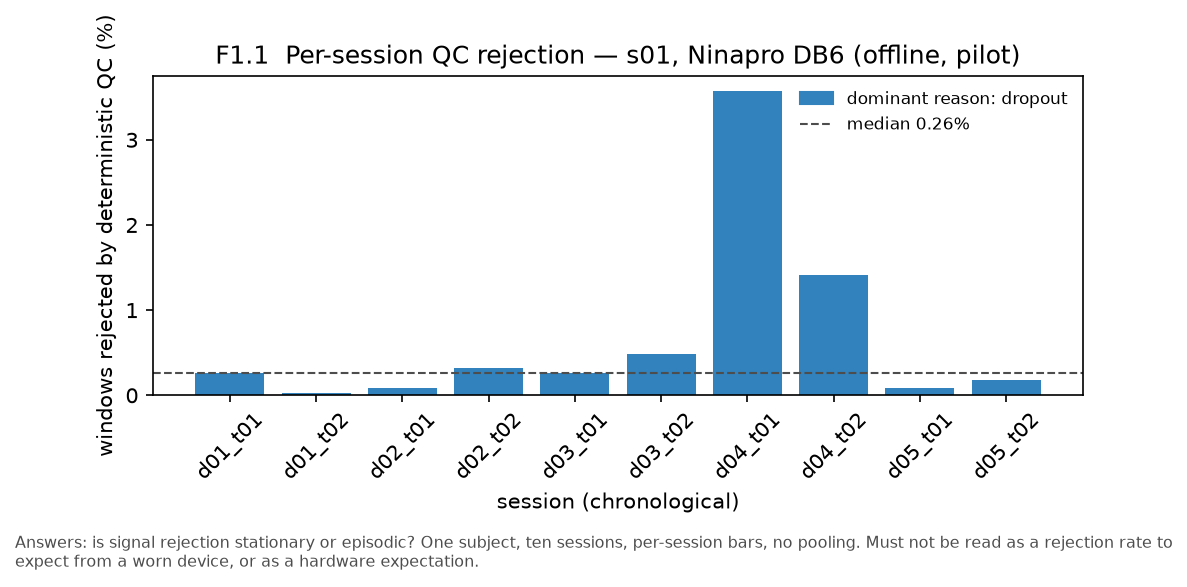

figures/F1_2_fault_detection_fed1e81a523e5d6e.png


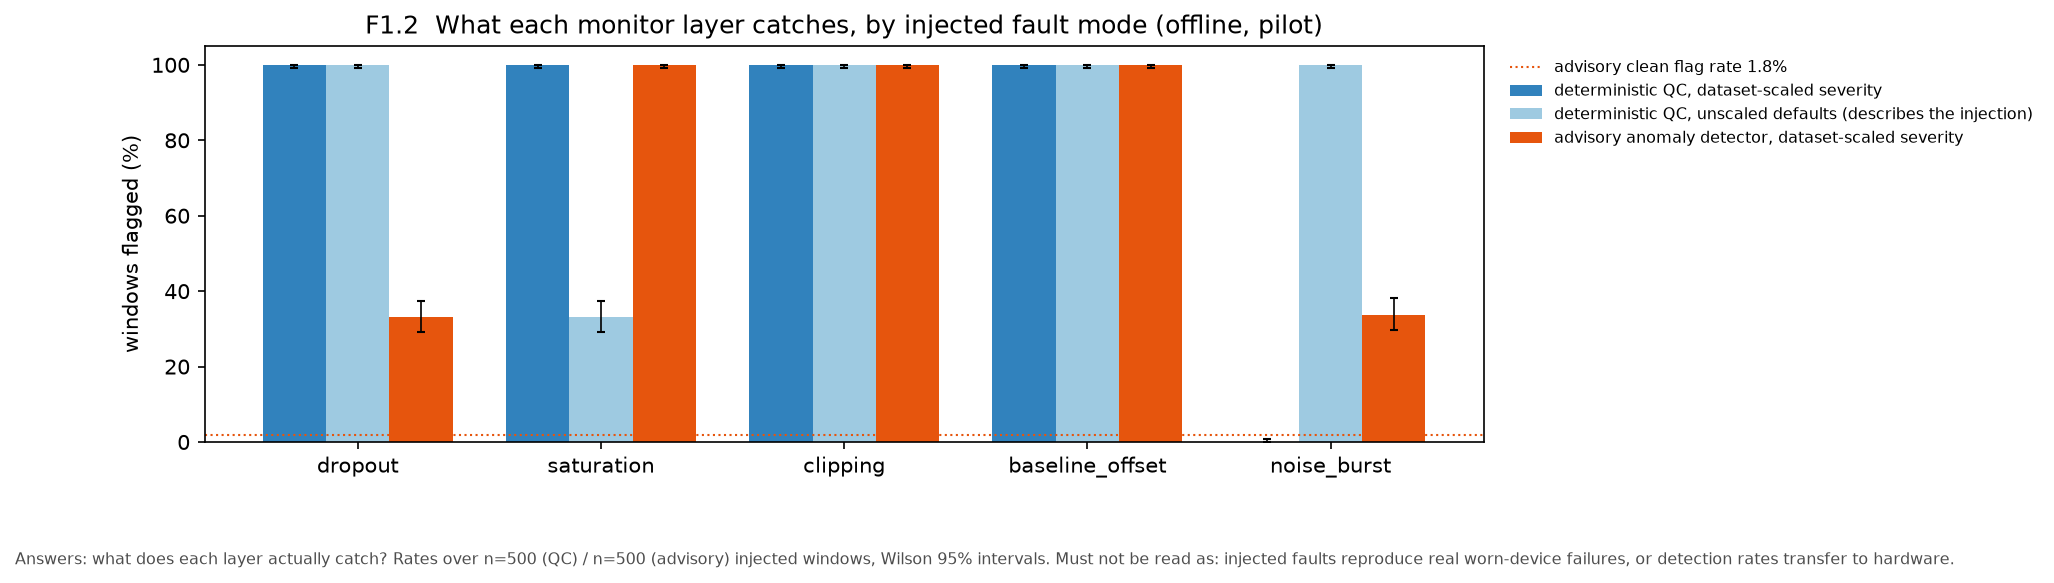

figures/F1_3_adaptive_threshold_fed1e81a523e5d6e.png


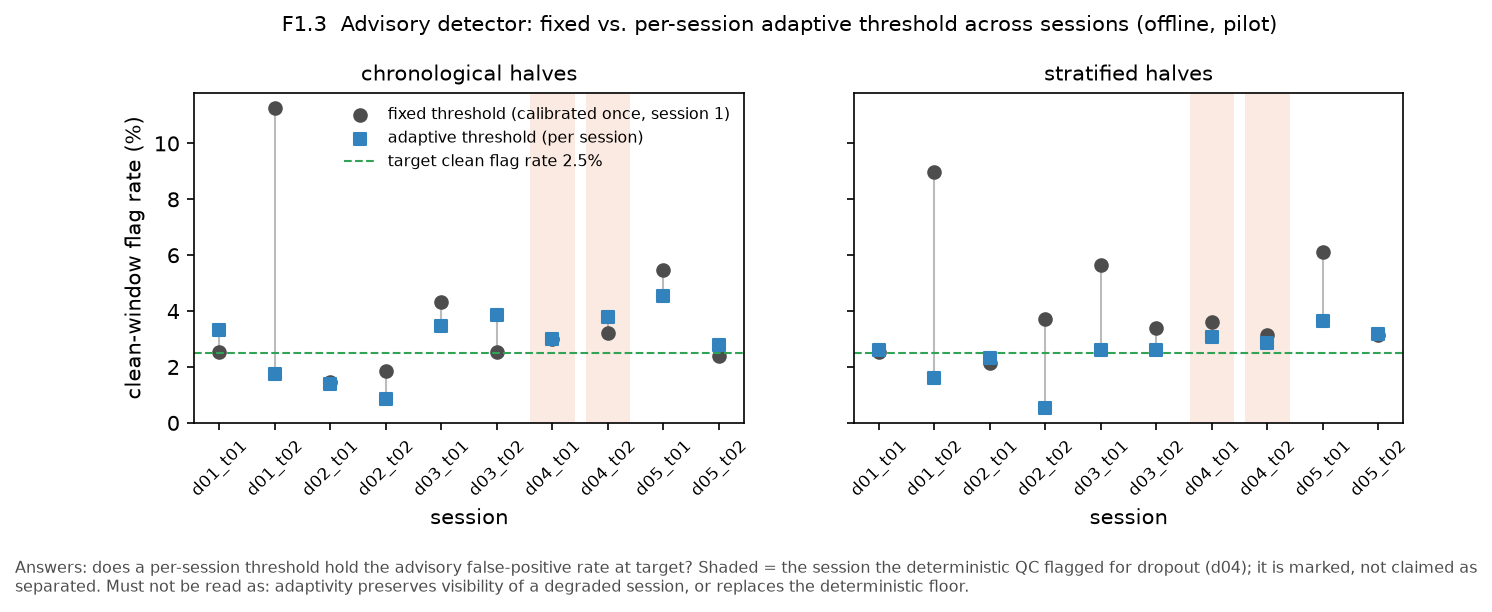

In [15]:
from IPython.display import Image, display

from figures.render import render_nb1

for path in render_nb1(RESULTS, REPO / "figures", STAMP):
    print(path.relative_to(REPO).as_posix())
    display(Image(filename=str(path)))

## 10. Reading, limitations, and what this notebook must not be used to claim

### What the executed evidence supports

- **Rejection on real EMG is low and episodic.** On `s01` the deterministic layer rejects well
  under 1% of windows overall and every rejection is `dropout`; one day (`d04`) rejects an order
  of magnitude more than the median. This suggests a fixed global QC budget is the wrong abstraction — the
  system needs to notice that *this session* is degrading relative to the wearer's own baseline.
- **Thresholds are not stale.** Re-derived percentiles match the committed config (§3).
- **Fault severity must be calibrated for a detection rate to mean anything.** At dataset-scaled
  severity the deterministic layer catches the nameable modes and leaves `noise_burst` to the
  advisor; the unscaled defaults produce numbers that describe the injection (§4).
- **The advisory detector models the activity distribution, not just electrode health.** Its
  clean false-positive rate depends on whether the test windows contain the gestures it was fit
  on (§5). The earlier "within-session drift" reading of that gap was a composition artefact and
  has been withdrawn.
- **Burst detectability has an energy floor** (§6): brief low-energy transients stay inside
  natural EMG variation at window granularity.
- **Per-session recalibration of the advisory threshold lowers between-session false positives**
  and **does not** make the QC-flagged session visible to the advisor (§7); that session was
  caught by the fixed deterministic floor.

### Limitations

- One subject for the QC audit and the fault/anomaly work; two in the cache. Pilot scale.
- One recording session supplies the clean windows for fault injection; one channel is assessed.
- `qc_powerline` is off; mains interference is not evaluated here.
- Laboratory data: DB6 was recorded to be repeatable, and its narrow failure modes (only
  `dropout` fired) may say as much about the dataset as about the checks.

### What this notebook must not be read as

- **Injected faults are not real worn-device failures.** They are calibrated synthetic
  corruptions of a laboratory recording.
- **Detection is not device safety.** A detection rate says what a check fires on, not what a
  device would do.
- **The anomaly detector is not a safety mechanism.** It is advisory, bounded, and sits above a
  fixed deterministic floor; it lowers confidence through the gate and can only ever reduce
  assist.

### Where this leads

Whether the signal is trustworthy is the first gate. `02_confidence_under_shift` asks the next
question: given a trustworthy signal, can the classifier's own *probability* be trusted when
conditions change? `03_when_not_to_help` then asks what warns the system when neither can be, and
what refusing to act costs.